## Let's run intron clustering to annotate alternative splicing events given observed junctions in our cells 

In [1]:
# Load LeafletSC 
import LeafletSC
import os
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

# Define path that contains junction files
juncs_path = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/"
print("The junctions are loaded from the following path: " + juncs_path) 

# print the files in the path 
print("The files in the path are: " + str(os.listdir(juncs_path)))

# define path for saving the output data 
output_path = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet"

# we provide a gtf file for the human genome as well to make better sense of the junctions that are detected in cells
# please replace with the path to the gtf file on your system
gtf_file="/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/genes/genes.gtf" 

The junctions are loaded from the following path: /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/
The files in the path are: ['M15_B001358_B008290_S303', 'J4_D045382_B009006_S220', 'A22_B000235_B007504_S22', 'F6_D045405_B009854_S126', 'N5_B002503_B009456_S17', 'E18_B001059_B009342_S114', 'D21_B002346_B009249_S261', 'P21_B000265_B009901_S381', 'P13_B000235_B007504_S373', 'P21_B000754_B008346_S381', 'C1_D045342_B009019_S49', 'C20_B003262_B007459_S68', 'M4_B001244_B006737_S292', 'O14_B002831_B007445_S350', 'H9_B001364_B009252_S249', 'J14_B003263_B007458_S230', 'H11_B000265_B009901_S179', 'D15_B001352_B008536_S87', 'P4_B002352_B009948_S364', 'M19_B002838_B008281_S307', 'M18_B001364_B009252_S78', 'J16_B000806_B008540_S232', 'L15_B002681_B009943_S279', 'D16_D045367_B009017_S88', 'M19_B001355_B006741_S307', 'D14_B002505_B008538_S86', 'L3_B000515_B008434_S267', 'A4_B001361_B007505_S4', 'K4_B003016_B007442_S244', 'K11_D045372_B009292_S59', 'B3_B001244_

In [2]:
# metadata file
metadata = "/gpfs/commons/projects/knowles_singlecell_splicing/TabulaSenis/data/AWS/metadata/tabula-muris-senis-full-metadata.csv"
metadata = pd.read_csv(metadata)
metadata.head()

/scratch/ipykernel_104582/2948469132.py:3: DtypeWarning: Columns (3,5,14) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata = pd.read_csv(metadata)


,index,age,batch,cell,cell_ontology_class,cell_ontology_id,free_annotation,method,mouse.id,n_counts,n_genes,sex,subtissue,tissue,tissue_free_annotation,louvain,leiden
0,AAACCTGCAGGGTACA-1-0-0-0-0,24m,0,MACA_24m_M_TONGUE_60_AAACCTGCAGGGTACA,keratinocyte,NaN,filiform,droplet,24-M-60,5482.0,2107.0,male,NaN,Tongue,Tongue,5,3
1,AAACCTGCAGTAAGCG-1-0-0-0-0,24m,0,MACA_24m_M_TONGUE_60_AAACCTGCAGTAAGCG,keratinocyte,NaN,suprabasal,droplet,24-M-60,21855.0,3481.0,male,NaN,Tongue,Tongue,27,31
2,AAACCTGTCATTATCC-1-0-0-0-0,24m,0,MACA_24m_M_TONGUE_60_AAACCTGTCATTATCC,keratinocyte,NaN,suprabasal,droplet,24-M-60,10942.0,2599.0,male,NaN,Tongue,Tongue,27,31
3,AAACGGGGTACAGTGG-1-0-0-0-0,24m,0,MACA_24m_M_TONGUE_60_AAACGGGGTACAGTGG,keratinocyte,NaN,suprabasal differentiating,droplet,24-M-60,20665.0,3468.0,male,NaN,Tongue,Tongue,24,11
4,AAACGGGGTCTTCTCG-1-0-0-0-0,24m,0,MACA_24m_M_TONGUE_60_AAACGGGGTCTTCTCG,keratinocyte,NaN,suprabasal differentiating,droplet,24-M-60,12925.0,3189.0,male,NaN,Tongue,Tongue,5,3


In [3]:
# find files associated with Astrocytes 
metadata[(metadata['cell_ontology_class'] == 'astrocyte') & (metadata['age'] == "18m")].sort_values(by='n_counts', ascending=False)

,index,age,batch,cell,cell_ontology_class,cell_ontology_id,free_annotation,method,mouse.id,n_counts,n_genes,sex,subtissue,tissue,tissue_free_annotation,louvain,leiden
256475,K2_B001373_B008595_S242.mm10-plus-3-0-1,18m,1,NaN,astrocyte,NaN,NaN,facs,18_47_F,9002290.0,6638.0,female,Hippocampus,Brain_Non-Myeloid,NaN,30,32
255097,F3_B002418_B006744_S123.mm10-plus-3-0-1,18m,1,NaN,astrocyte,NaN,NaN,facs,18_47_F,8293882.0,2614.0,female,Cortex,Brain_Non-Myeloid,NaN,30,32
250533,F7_D045344_B009254_S151.mm10-plus-1-0-1,18m,1,NaN,astrocyte,NaN,NaN,facs,18_45_M,7006834.0,1826.0,male,Cortex,Brain_Non-Myeloid,NaN,30,32
249910,D20_D045344_B009254_S116.mm10-plus-1-0-1,18m,1,NaN,astrocyte,NaN,NaN,facs,18_45_M,6386491.0,3673.0,male,Cortex,Brain_Non-Myeloid,NaN,30,32
247892,K8_B001059_B009342_S248.mm10-plus-0-0-1,18m,1,NaN,astrocyte,NaN,NaN,facs,18_46_F,5673606.0,1840.0,female,Striatum,Brain_Non-Myeloid,NaN,33,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
256280,J8_B002418_B006744_S224.mm10-plus-3-0-1,18m,1,NaN,astrocyte,NaN,NaN,facs,18_47_F,188239.0,566.0,female,Cortex,Brain_Non-Myeloid,NaN,30,32
264315,K4_B001374_B008586_S244.mm10-plus-5-0-1,18m,1,NaN,astrocyte,NaN,NaN,facs,18_47_F,187105.0,576.0,female,Hippocampus,Brain_Non-Myeloid,NaN,38,32
250382,F17_B002342_B009298_S149.mm10-plus-1-0-1,18m,1,NaN,astrocyte,NaN,NaN,facs,18_46_F,172115.0,572.0,female,Cortex,Brain_Non-Myeloid,NaN,6,32
249107,A18_D045326_B009461_S138.mm10-plus-1-0-1,18m,1,NaN,astrocyte,NaN,NaN,facs,18_45_M,146075.0,513.0,male,Cerebellum,Brain_Non-Myeloid,NaN,46,30


In [4]:
# subset metadata to only facs under method 
metadata = metadata[metadata['method'] == 'facs']

Text(0, 0.5, '# of genes detected in cell')

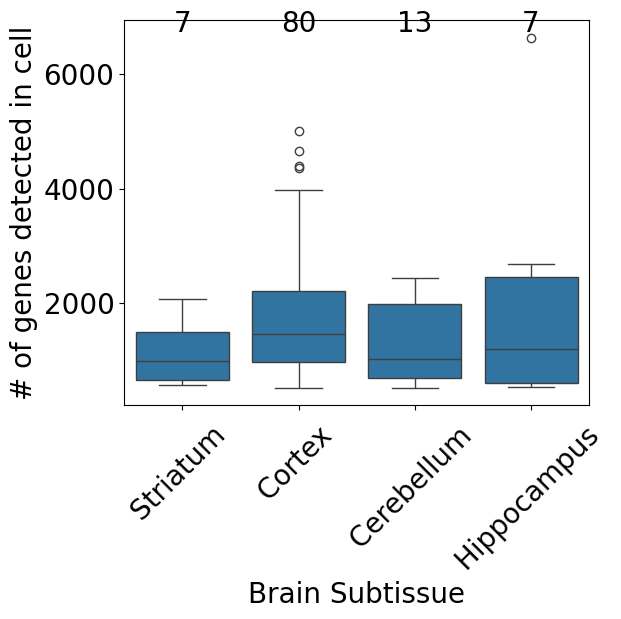

In [5]:
# make a histogram of n_genes across the following cells 
astros = metadata[(metadata['cell_ontology_class'] == 'astrocyte') & (metadata['age'] == "18m")]

# plot violin plots showing n_genes coloured by subtissue 
plt.figure(figsize=(6, 5))

# increase font of everything 
plt.rcParams.update({'font.size': 20})
sns.boxplot(x='subtissue', y='n_genes', data=astros)
plt.xticks(rotation=45)

# print number of cells in each group on top of corresponding boxplot 
for i, group in enumerate(astros['subtissue'].unique()):
    n = len(astros[astros['subtissue'] == group])
    plt.text(i, astros['n_genes'].max(), n, ha='center', va='bottom')

# xlab Brain Subtissue 
plt.xlabel('Brain Subtissue')

# ylab to be Number of genes detected 
plt.ylabel('# of genes detected in cell')

In [6]:
brain_only = metadata[metadata['tissue'].isin(['Brain_Non-Myeloid', 'Brain_Myeloid'])]
brain_only.cell_ontology_class.value_counts()

cell_ontology_class
microglial cell                    13268
endothelial cell                    2232
oligodendrocyte                     2094
astrocyte                            592
brain pericyte                       484
neuron                               484
macrophage                           312
oligodendrocyte precursor cell       312
interneuron                          240
neuroepithelial cell                 151
CD8-positive, alpha-beta T cell      104
medium spiny neuron                  103
neuronal stem cell                    97
T cell                                67
ependymal cell                        55
Bergmann glial cell                   54
mature NK T cell                      17
Name: count, dtype: int64

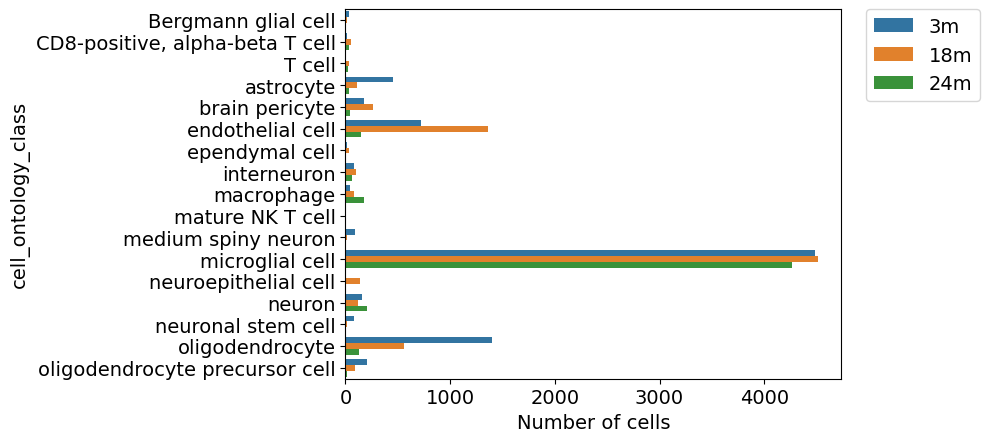

In [7]:
age_tissue = brain_only.groupby(['age', 'cell_ontology_class']).size()

# make a dataframe and keep only Brain_Non-Myeloid and Brain_Myeloid cells 
age_tissue = age_tissue.reset_index()
age_tissue = age_tissue.rename(columns={0: 'count'})

# specify order of cateogries for age column, 3m, 18, 24m
age_tissue['age'] = pd.Categorical(age_tissue['age'], categories=['3m', '18m', '24m']) 

# make barplot using age_tissue 
# increase font size globally for all plots 
plt.rcParams.update({'font.size': 14})

# make barplot so cell_only_class are along y-axis
sns.barplot(x='count', y='cell_ontology_class', hue='age', data=age_tissue)

# add yaxis label
plt.xlabel('Number of cells')

# put legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

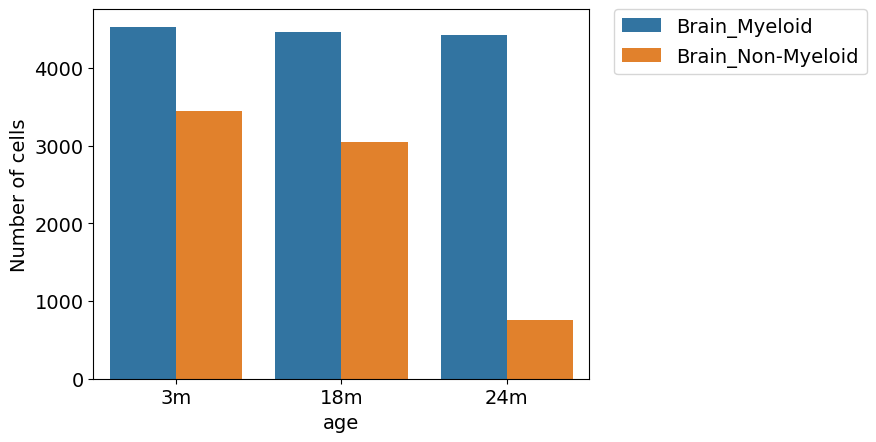

In [8]:
age_tissue = metadata.groupby(['age', 'tissue']).size()
# make a dataframe and keep only Brain_Non-Myeloid and Brain_Myeloid cells 
age_tissue = age_tissue.reset_index()
age_tissue = age_tissue[age_tissue['tissue'].isin(['Brain_Non-Myeloid', 'Brain_Myeloid'])]
age_tissue = age_tissue.rename(columns={0: 'count'})

# specify order of cateogries for age column, 3m, 18, 24m
age_tissue['age'] = pd.Categorical(age_tissue['age'], categories=['3m', '18m', '24m']) 

# make barplot using age_tissue 
# increase font size globally for all plots 
plt.rcParams.update({'font.size': 14})

sns.barplot(x='age', y='count', hue='tissue', data=age_tissue)

# add yaxis label
plt.ylabel('Number of cells')

# put legend outside of plot
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.)

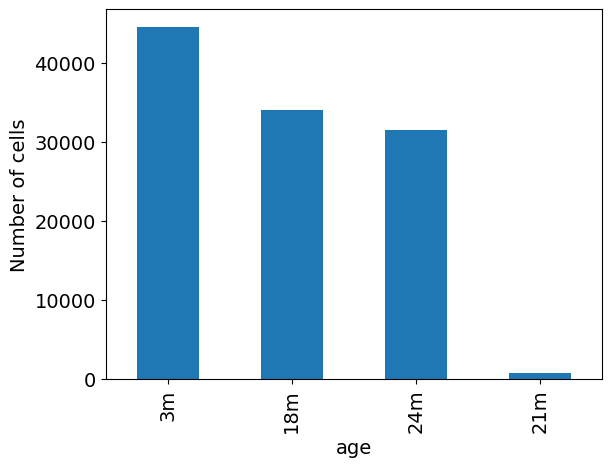

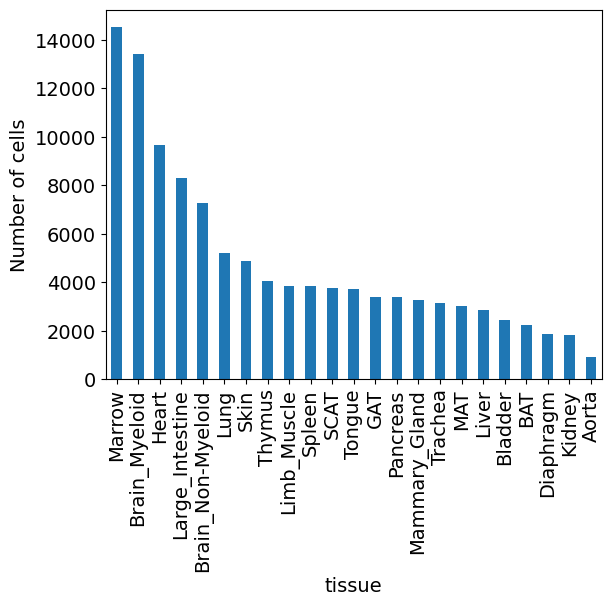

/scratch/ipykernel_104582/3953807818.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  metadata.groupby(['age', 'tissue']).size()


age  tissue           
18m  Aorta                 316
     BAT                   662
     Bladder               692
     Brain_Myeloid        4461
     Brain_Non-Myeloid    3051
                          ... 
3m   Skin                 2346
     Spleen               1702
     Thymus               1359
     Tongue               1418
     Trachea              1354
Length: 92, dtype: int64

In [9]:
# print number of cells in each age group mouse and make barplot 
# make age column categories in order 3m, 18m, 21m, 24m 
metadata['age'] = metadata['age'].astype('category')

# make barplot summarizing counts of cells in each age group 
metadata['age'].value_counts().plot(kind='bar')
# add y axis 
plt.ylabel('Number of cells')
# print plot 
plt.show()

# make barplot summarizing counts of cells in each group 'Brain_Non-Myeloid' and 'Brain_Myeloid'
metadata['tissue'].value_counts().plot(kind='bar')
# add y axis
plt.ylabel('Number of cells')
# print plot 
plt.show()

# lastly within each age group, print nunmber of Brain_Non-Myeloid and Brain_Myeloid cells
metadata.groupby(['age', 'tissue']).size()


### Let's first define some parameters for the analysis

In [10]:
metadata.head()

,index,age,batch,cell,cell_ontology_class,cell_ontology_id,free_annotation,method,mouse.id,n_counts,n_genes,sex,subtissue,tissue,tissue_free_annotation,louvain,leiden
245389,A10_B000497_B009023_S10.mm10-plus-0-0-1,18m,1,NaN,bulge keratinocyte,NaN,NaN,facs,18_53_M,1009823.0,2706.0,male,NaN,Skin,NaN,39,45
245390,A10_B000756_B007446_S10.mm10-plus-0-0-1,18m,1,NaN,pancreatic B cell,NaN,pancreatic B cell,facs,18_45_M,978738.0,3212.0,male,Endocrine,Pancreas,NaN,14,16
245391,A10_B000802_B009022_S10.mm10-plus-0-0-1,18m,1,NaN,bulge keratinocyte,NaN,outer bulge,facs,18_47_F,419667.0,2243.0,female,Skin Anagen,Skin,NaN,39,45
245392,A10_B000927_B007456_S10.mm10-plus-0-0-1,18m,1,NaN,skeletal muscle satellite cell,NaN,NaN,facs,18_46_F,878796.0,2789.0,female,Muscle Diaphragm,Limb_Muscle,NaN,23,28
245393,A10_B001361_B007505_S10.mm10-plus-0-0-1,18m,1,NaN,B cell,NaN,B cell,facs,18_46_F,6587.0,1237.0,female,RV,Heart,NaN,0,0


In [11]:
# get cell ids from metadata "index" column by keeping everything before the ".mm10"
metadata['cell_id'] = metadata['index'].str.split('.').str[0]
cell_ids_brain = metadata[metadata['tissue'].isin(['Brain_Non-Myeloid', 'Brain_Myeloid'])]['cell_id']
cell_ids_brain = cell_ids_brain.values

In [12]:
# filter further to just cells in the cell ontology class Astrocyte
cell_ids_astro = metadata[(metadata['cell_ontology_class'] == 'astrocyte') & (metadata['age'] == '18m')]['cell_id']
cell_ids_astro = cell_ids_astro.values

In [13]:
# list the first 5 files or folders in juncs_path
all_files = os.listdir(juncs_path)

# which all_files in cell_ids_brain
portion_in_list2 = [x for x in all_files if x in cell_ids_astro]

In [14]:
# junc_files defines a path for where junction files can be found, in this case, the path is defined above
junc_files = portion_in_list2

In [15]:
# append jjuncs_path befpre junc_files values
junc_files = [juncs_path + x for x in junc_files]

# add "/" at the end of every file in junc_files 
junc_files = [x + "/junctions_with_barcodes.bed" for x in junc_files]

In [16]:
# read each junc file in portion_in_list2 into one dataframe 
df = pd.DataFrame()
for file in junc_files:
    file_path = file
    df_temp = pd.read_csv(file_path, sep='\t', header=None)
    df = pd.concat([df, df_temp])

In [17]:
# get sum of values in the 4th column 
df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13
0,JH584304.1,83988,106526,JUNC00001219,1,+,83988,106526,"255,0,0",2,"67,29","0,22509",1,C10_B002342_B009298_S70:1
1,JH584304.1,86479,94763,JUNC00001220,2,-,86479,94763,"255,0,0",2,"62,38","0,8246",1,C10_B002342_B009298_S70:2
2,JH584304.1,86479,104344,JUNC00001221,2,-,86479,104344,"255,0,0",2,"62,38","0,17827",1,C10_B002342_B009298_S70:2
3,JH584304.1,86479,106213,JUNC00001223,1,-,86479,106213,"255,0,0",2,"62,37","0,19697",1,C10_B002342_B009298_S70:1
4,JH584304.1,86479,110891,JUNC00001222,2,-,86479,110891,"255,0,0",2,"62,38","0,24374",1,C10_B002342_B009298_S70:2


In [18]:
# get sum of total junction counts across all these cells 
df[4].sum() / 1000000

112.922072

In [19]:
from LeafletSC.clustering.find_intron_clusters import main as find_intron_clusters
from LeafletSC.clustering.prepare_model_input import main as prep_model_input
from LeafletSC.clustering.find_intron_clusters import visualize_local_events

# define additional parameters 
sequencing_type = "single_cell"

# ensure output files are to be saved in output_path 
output_file = output_path + "/18mo_intron_astros_clusters"
junc_bed_file= output_path + "/18mo_juncs_astros.bed" # you can load this file into IGV to visualize the junction coordinates 
min_intron_length = 50
max_intron_length = 500000
threshold_inc = 0.01 
min_junc_reads = 2
min_num_cells_wjunc = 2
keep_singletons = False # ignore junctions that do not share splice sites with any other junction (likely const)
junc_suffix = "*with_barcodes.bed" # depends on how you ran regtools 

### Run intron clustering 

In [20]:
all_juncs_df = find_intron_clusters(junc_files=junc_files, gtf_file=gtf_file, output_file=output_file, 
                       sequencing_type=sequencing_type, junc_bed_file=junc_bed_file, 
                       threshold_inc=threshold_inc, min_intron = min_intron_length,
                       max_intron=max_intron_length, min_junc_reads=min_junc_reads,
                       singleton=keep_singletons,
                       junc_suffix=junc_suffix, min_num_cells_wjunc=min_num_cells_wjunc, filter_shared_ss=True, 
                       run_notebook = True)

Loading files obtained from single_cell sequencing


  5%|▍         | 5/107 [00:00<00:02, 46.20it/s]

Reading in junction files from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/C10_B002342_B009298_S70/junctions_with_barcodes.bed
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/M19_B002342_B009298_S19/junctions_with_barcodes.bed
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/C11_D045344_B009254_S83/junctions_with_barcodes.bed
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/J17_B002342_B009298_S245/junctions_with_barcodes.bed
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junct

 17%|█▋        | 18/107 [00:00<00:01, 55.09it/s]

Reading in junction files from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/C9_B001366_B009293_S249/junctions_with_barcodes.bed
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/O18_B002418_B006744_S354/junctions_with_barcodes.bed
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/N1_B002418_B006744_S313/junctions_with_barcodes.bed
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/K16_B002418_B006744_S256/junctions_with_barcodes.bed
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junc

...

Reading in junction files from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/E5_B002342_B009298_S113/junctions_with_barcodes.bed
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/E12_B002418_B006744_S108/junctions_with_barcodes.bed
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/C8_B001373_B008595_S56/junctions_with_barcodes.bed
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/C10_B002418_B006744_S58/junctions_with_barcodes.bed
The number of junction files to be processed is 1
Reading in junction files from /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/juncti

100%|██████████| 107/107 [00:01<00:00, 71.29it/s]


The number of junctions after filtering for intron length is 124614
Making gr object from all junctions across all cell types
The number of junctions after filtering by min_junc_reads 108369
The gtf file you provided is /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/genome_files/gencode.vM19/genes/genes.gtf
Reading the gtf may take a minute...


INFO:root:Extracted GTF attributes: ['gene_id', 'gene_type', 'gene_name', 'havana_gene', 'transcript_id', 'transcript_type', 'transcript_name', 'transcript_support_level', 'tag', 'havana_transcript', 'exon_id', 'protein_id', 'ccdsid', 'ont']


Reading gtf file took 36.39 seconds
The number of unique exons is 437943
The number of unique transcript ids is 135995
The number of unique gene ids is 54446
+++++++++++++++++++++++++++++++++++++++++++++++++++++++
Done extracting exons from gtf file
Annotating junctions with known exons based on input gtf file
The number of junctions after assessing distance to exons is 85922
Clustering intron splicing events by gene_id
The number of clusters after clustering by gene_id is 78034
+--------------+-----------+-----------+--------------+-------+
| Chromosome   | Start     | End       | Strand       | +10   |
| (category)   | (int64)   | (int64)   | (category)   | ...   |
|--------------+-----------+-----------+--------------+-------|
| 1            | 10039879  | 10045075  | +            | ...   |
| 1            | 10039879  | 10045075  | +            | ...   |
| 1            | 10039879  | 10045075  | +            | ...   |
| 1            | 10039879  | 10045075  | +            | ...   |
| ..

In [21]:
# load bed file 
import pandas as pd
juncs_bed = pd.read_csv(junc_bed_file, sep="\t", header=None)
# remove columns 3 and 4 
juncs_bed = juncs_bed.drop(columns=[3, 4])
juncs_bed.columns = ["Chromosome", "Start", "End", "Strand", "junction_id", "Start_b", "End_b", "gene_id", "gene_name", "transcript_id", "exon_id"]

# cmobine with all_juncs_df and prep df for visualization 
dat_vis = all_juncs_df[["chrom", "chromStart", "chromEnd", "strand", "intron_length", "counts_total", "junction_id", "Cluster"]]
dat_vis = dat_vis.drop_duplicates()
# merge dat_vis with juncs_bed using all common columns 
dat_vis = dat_vis.merge(juncs_bed, how="left", on=["junction_id"])

In [22]:
dat_vis

,chrom,chromStart,chromEnd,strand,intron_length,counts_total,junction_id,Cluster,Chromosome,Start,End,Strand,Start_b,End_b,gene_id,gene_name,transcript_id,exon_id
0,10,100584009,100586190,-,2181,377,10_100584009_100586190,2661,10,100584009,100586190,-,100583913,100584009,ENSMUSG00000046567.10,4930430F08Rik,ENSMUST00000054471.9,ENSMUSE00000414103.3
1,10,100584009,100589026,-,5017,18,10_100584009_100589026,2661,10,100584009,100589026,-,100583913,100584009,ENSMUSG00000046567.10,4930430F08Rik,ENSMUST00000054471.9,ENSMUSE00000414103.3
2,10,100586308,100589026,-,2718,411,10_100586308_100589026,2661,10,100586308,100589026,-,100586190,100586308,ENSMUSG00000046567.10,4930430F08Rik,ENSMUST00000054471.9,ENSMUSE00000362876.3
3,10,105826591,105829847,-,3256,17,10_105826591_105829847,2649,10,105826591,105829847,-,105826572,105826591,ENSMUSG00000036009.16,Mettl25,ENSMUST00000176040.1,ENSMUSE00000964449.1
4,10,105826591,105832850,-,6259,16,10_105826591_105832850,2649,10,105826591,105832850,-,105826572,105826591,ENSMUSG00000036009.16,Mettl25,ENSMUST00000176040.1,ENSMUSE00000964449.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10227,X,95131015,95196409,-,65394,177,X_95131015_95196409,4406,X,95131015,95196409,-,95130835,95131015,ENSMUSG00000025656.17,Arhgef9,ENSMUST00000113876.8,ENSMUSE00001307925.1
10228,X,99467573,99468122,-,549,45,X_99467573_99468122,4441,X,99467573,99468122,-,99466145,99467573,ENSMUSG00000034403.16,Pja1,ENSMUST00000113797.3,ENSMUSE00000696987.2
10229,X,99467582,99468122,-,540,218,X_99467582_99468122,4441,X,99467582,99468122,-,99465737,99467582,ENSMUSG00000034403.16,Pja1,ENSMUST00000113790.7,ENSMUSE00000387835.4
10230,Y,90793417,90816348,+,22931,5874,Y_90793417_90816348,4462,Y,90793417,90816348,+,90793295,90793417,ENSMUSG00000096768.7,Gm47283,ENSMUST00000179483.7,ENSMUSE00001306121.1


In [23]:
print(len(dat_vis.gene_id.unique()))

2874


In [24]:
# viusalize junction 11_68822665_68829914

     chrom  chromStart_kb  chromEnd_kb strand  intron_length  counts_total  \
7010     5     115330.658   115331.449      +            791            42   
7011     5     115330.658   115332.116      +           1458          1226   
7012     5     115331.539   115332.116      +            577            45   

         Start_b       End_b               exon_id  
7010  115330.577  115330.658  ENSMUSE00000824766.1  
7011  115330.577  115330.658  ENSMUSE00000824766.1  
7012  115331.449  115331.539  ENSMUSE00000783786.1  
The junction of interest is 5_115330658_115332116


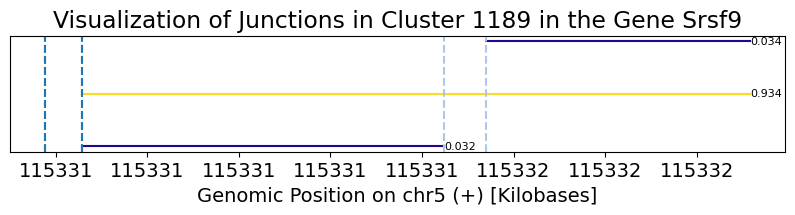

In [25]:
#from LeafletSC.clustering.find_intron_clusters import visualize_junctions
junc_id = all_juncs_df.junction_id.sample(1).values[0]
j = junc_id
visualize_local_events(dat_vis, j, p_usage_ratio=True)

In [26]:
# get average number of junctions per cluster here 
avg_juncs_per_cluster = all_juncs_df.groupby("Cluster").size().mean()
print("The average number of junctions per cluster is: " + str(avg_juncs_per_cluster))

The average number of junctions per cluster is: 18.02326225422321


### Stop here for now

### Now let's convert the intron clusters to a format that can be used by LeafletSC

In [29]:
intron_clusters = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/18mo_intron_astros_clusters_50_500000_2_20240501_single_cell.gz" # path to the intron clusters file
output_file = output_path + "Leaflet18mo_model_input" # name of the output file
has_genes = "yes" # since we used a gtf file to obtain the intron clusters, we can set this to yes
chunk_size = 5000 # number of junctions to process at a time from the intron clusters files
metadata = None # can replace with path, if metadata is available for cells (cell type, origin, library ID...)

In [30]:
prep_model_input(intron_clusters, output_file, has_genes, chunk_size, metadata)

The intron clusters file you provided is /gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/Leaflet/18mo_intron_astros_clusters_50_500000_2_20240501_single_cell.gz, reading in chunks of 5000 lines
Processing intron clusters


14it [00:00, 16.73it/s]


Done processing intron clusters
The number of intron clusters evaluated is 3611
The number of junctions evaluated is 10232
The number of cells evaluated is 107
The number of clusters with only one junction is 0
A gtf file was used to generate intron clusters
The number of total cells evaluated is 107
The number of cells per cell type is:
cell_type
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/A10_B002342_B009298_S22/junctions_with_barcodes.bed          1
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/A12_B002418_B006744_S12/junctions_with_barcodes.bed          1
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/A13_D045326_B009461_S133/junctions_with_barcodes.bed         1
/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/junctions/18_month/A17_B002342_B009298_S29/junctions_with_barcodes.bed          1
/gpfs/commons/groups/knowles_lab/Karin

### Take a quick look at the input file that will go into the model to get familiarized with all the columns

In [31]:
model_input_data = "/gpfs/commons/groups/knowles_lab/Karin/Leaflet-analysis-WD/TabulaSenis/LeafletLeaflet18mo_model_input.h5"
summarized_data = pd.read_hdf(model_input_data, 'df')
print(summarized_data.head())

                                             cell_id  Cluster  Cluster_Counts  \
0  A10_B002342_B009298_S22_/gpfs/commons/groups/k...       19             292   
1  A10_B002342_B009298_S22_/gpfs/commons/groups/k...      110             772   
2  A10_B002342_B009298_S22_/gpfs/commons/groups/k...      110             772   
3  A10_B002342_B009298_S22_/gpfs/commons/groups/k...      110             772   
4  A10_B002342_B009298_S22_/gpfs/commons/groups/k...      110             772   

             junction_id                gene_id  junc_count  \
0    1_21226679_21229590  ENSMUSG00000025933.15         292   
1  1_161036244_161036548  ENSMUSG00000053332.13         113   
2  1_161036579_161036819  ENSMUSG00000053332.13         124   
3  1_161036852_161037287  ENSMUSG00000053332.13         112   
4  1_161036852_161037504  ENSMUSG00000053332.13          14   

                                           cell_type  junc_ratio  \
0  /gpfs/commons/groups/knowles_lab/Karin/Leaflet...    1.000000  

#### Note that fow now, the values in cell_type default to the cell's path, in the future it will be possible to specify the cell type in the metadata file

In [32]:
# let's see all the columns in the summarized data
print(summarized_data.columns)

Index(['cell_id', 'Cluster', 'Cluster_Counts', 'junction_id', 'gene_id',
       'junc_count', 'cell_type', 'junc_ratio', 'cell_id_index',
       'junction_id_index'],
      dtype='object')


#### We can quickly visualize the overall junction usage ratio distribution across all cells

In [ ]:
summarized_data.head()

In [ ]:
print(len(summarized_data.cell_id.unique()))

In [ ]:
all_cell_ids = summarized_data.cell_id

# clean up each cell_id using .str.split("_/gpfs")[0]
all_cell_ids_clean = [x.split("_/gpfs")[0] for x in all_cell_ids]
summarized_data["cell_id_clean"] = all_cell_ids_clean

In [ ]:
summarized_data.head()

In [ ]:
brain_only['cell_id'] = brain_only['index'].str.split('.').str[0]
brain_only = brain_only[brain_only["age"] == "18m"]
brain_only

In [ ]:
brain_only = brain_only[["cell_id", "cell_ontology_class", "sex", "subtissue", "tissue", "mouse.id"]]
brain_only

In [ ]:
# merge with sumamrized_datA_df
# remove cell_id columb from summarized_data 
summarized_data = summarized_data.drop(columns=["cell_id"])
# rename cell_id_clean to cell_id
summarized_data = summarized_data.rename(columns={"cell_id_clean": "cell_id"})
summarized_data = summarized_data.merge(brain_only, how="left", on="cell_id")
summarized_data.head()

In [ ]:
print(model_input_data)

In [ ]:
# rewrite the summarized data to a new file h5 format 
summarized_data.to_hdf(model_input_data, key='df', mode='w', complevel=9, complib='zlib', format="table")  

### Now we have everything need to run the Leaflet mixture model! Please refer to the next notebook for the next steps.